# Data Analytics in Building Science (AR32203)
## Major Assignment: Occupancy Pattern Detection and Energy-IAQ Analysis

This notebook contains the complete workflow for data preprocessing, exploratory data analysis, clustering-based occupancy detection, and predictive modeling (Linear Regression and Random Forest).

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='whitegrid')

## 2. Data Collection and Pre-processing
Here we load the 15-minute resolution datasets (Indoor, Outdoor, Energy), clean them, handle missing values via forward-filling, and merge them on a unified timestamp.

In [2]:
# Load Indoor Data
indoor_df = pd.read_excel('Indoor Air Quality.xlsx', sheet_name='PAoffice')
indoor_df.columns = ['Date', 'Time', 'CO2_indoor', 'Temp_indoor', 'Pressure_indoor', 'RH_indoor', 'DewPoint_indoor', 'AbsHumidity_indoor']
indoor_df['Datetime'] = pd.to_datetime(indoor_df['Date'].astype(str) + ' ' + indoor_df['Time'].astype(str), errors='coerce')
for col in ['CO2_indoor', 'Temp_indoor', 'Pressure_indoor', 'RH_indoor', 'DewPoint_indoor', 'AbsHumidity_indoor']:
    indoor_df[col] = pd.to_numeric(indoor_df[col], errors='coerce')
indoor_df.replace("###", np.nan, inplace=True)
indoor_df.ffill(inplace=True)
indoor_df = indoor_df.sort_values('Datetime').dropna(subset=['Datetime'])

# Load Outdoor Data
outdoor_df = pd.read_excel('Outdoor Air Quality.xlsx', sheet_name='OUTDOOR DATA - Air quality', skiprows=8, header=None)
outdoor_df.columns = ['Datetime', 'Time', 'CO2_outdoor', 'Temp_outdoor', 'Pressure_outdoor', 'RH_outdoor', 'DewPoint_outdoor', 'AbsHumidity_outdoor']
outdoor_df['Datetime'] = pd.to_datetime(outdoor_df['Datetime'], errors='coerce')
for col in ['CO2_outdoor', 'Temp_outdoor', 'Pressure_outdoor', 'RH_outdoor', 'DewPoint_outdoor', 'AbsHumidity_outdoor']:
    outdoor_df[col] = pd.to_numeric(outdoor_df[col], errors='coerce')
outdoor_df.ffill(inplace=True)
outdoor_df = outdoor_df.sort_values('Datetime').dropna(subset=['Datetime'])

# Load Energy Data
energy_df = pd.read_excel('ENERGYDATA.xlsx', sheet_name='ENERGYDATA')
energy_df.columns = ['Datetime', 'Computer', 'Plug_Load', 'AC_Load', 'Light_Fan']
energy_df['Datetime'] = pd.to_datetime(energy_df['Datetime'], errors='coerce')
energy_df.replace("No CT", np.nan, inplace=True)
for col in ['Computer', 'Plug_Load', 'AC_Load', 'Light_Fan']:
    energy_df[col] = pd.to_numeric(energy_df[col], errors='coerce')
energy_df.fillna(0, inplace=True)
energy_df['Total_Energy'] = energy_df['Computer'] + energy_df['Plug_Load'] + energy_df['AC_Load'] + energy_df['Light_Fan']
energy_df = energy_df.sort_values('Datetime').dropna(subset=['Datetime'])

# Merge Datasets
merged = pd.merge_asof(indoor_df, outdoor_df, on='Datetime', direction='nearest', tolerance=pd.Timedelta('5min'))
df = pd.merge_asof(merged, energy_df, on='Datetime', direction='nearest', tolerance=pd.Timedelta('5min'))

# Feature Engineering: Outlier Detection (Z-scores)
df['Z_Total_Energy'] = zscore(df['Total_Energy'], nan_policy='omit')
df['Is_Energy_Outlier'] = np.abs(df['Z_Total_Energy']) > 3

# Summary Statistics
df.describe()

,Date,CO2_indoor,Temp_indoor,Pressure_indoor,RH_indoor,DewPoint_indoor,AbsHumidity_indoor,Datetime,CO2_outdoor,Temp_outdoor,Pressure_outdoor,RH_outdoor,DewPoint_outdoor,AbsHumidity_outdoor,Computer,Plug_Load,AC_Load,Light_Fan,Total_Energy,Z_Total_Energy
count,38945,38945.000000,38945.000000,38945.000000,38945.000000,38945.000000,38945.000000,38945,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,31361.000000,31361.000000,31361.000000,31361.000000,31361.000000,3.136100e+04
mean,2023-07-21 13:10:05.191937,427.707767,27.360108,1002.582231,64.796631,19.953694,17.293108,2023-07-22 01:02:28.802953,400.917431,25.822936,1003.697248,77.456269,21.376453,19.098165,0.008144,0.000458,0.030175,0.006166,0.044943,4.622006e-17
min,2023-01-01 00:00:00,298.000000,16.700000,984.000000,31.800000,7.900000,7.900000,2023-01-01 00:00:00,172.000000,13.300000,986.000000,33.400000,6.000000,6.900000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.842378e-01
25%,2023-04-11 00:00:00,355.000000,24.300000,997.000000,58.500000,16.300000,13.500000,2023-04-11 23:00:00,398.000000,23.400000,998.000000,73.850000,17.950000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.842378e-01
50%,2023-07-22 00:00:00,382.000000,28.500000,1003.000000,67.000000,20.600000,17.500000,2023-07-22 02:30:00,414.000000,27.000000,1004.000000,79.900000,22.400000,19.600000,0.000000,0.000000,0.000000,0.000000,0.000300,-2.823405e-01
75%,2023-10-31 00:00:00,439.000000,30.600000,1008.000000,71.900000,23.800000,21.100000,2023-10-31 04:15:00,437.000000,29.300000,1009.000000,85.200000,25.700000,23.700000,0.016700,0.000000,0.000100,0.000000,0.022100,-1.444673e-01
max,2024-02-09 00:00:00,1895.000000,35.900000,1016.000000,85.700000,27.700000,26.400000,2024-02-09 00:00:00,535.000000,36.600000,1015.000000,93.600000,28.700000,27.900000,0.153600,0.156800,1.018000,0.105100,1.111000,6.742234e+00
std,NaN,134.642182,4.416130,6.138364,9.553810,4.365712,4.253178,NaN,73.332648,4.928693,6.241320,11.091724,4.978133,5.062341,0.013251,0.003580,0.146414,0.020736,0.158119,1.000016e+00


## 3. Exploratory Data Analysis (EDA)
Visualizing trends, correlations, and performing time-series decomposition to understand underlying patterns.

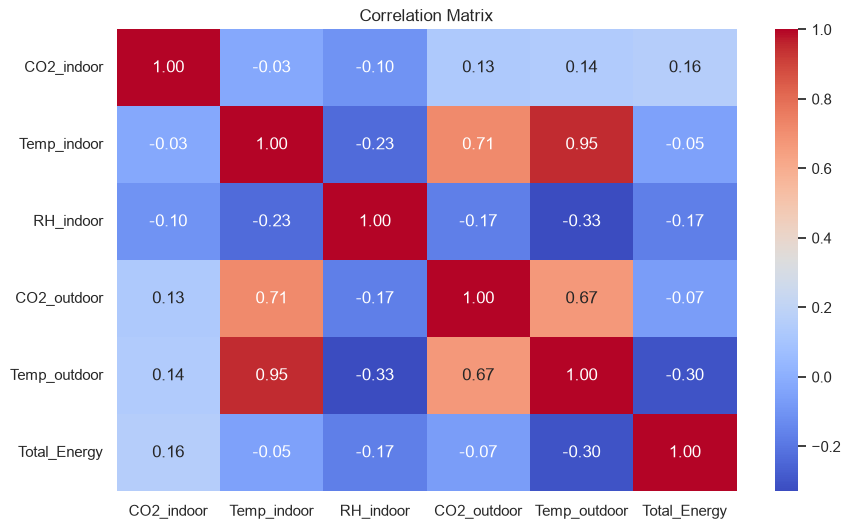

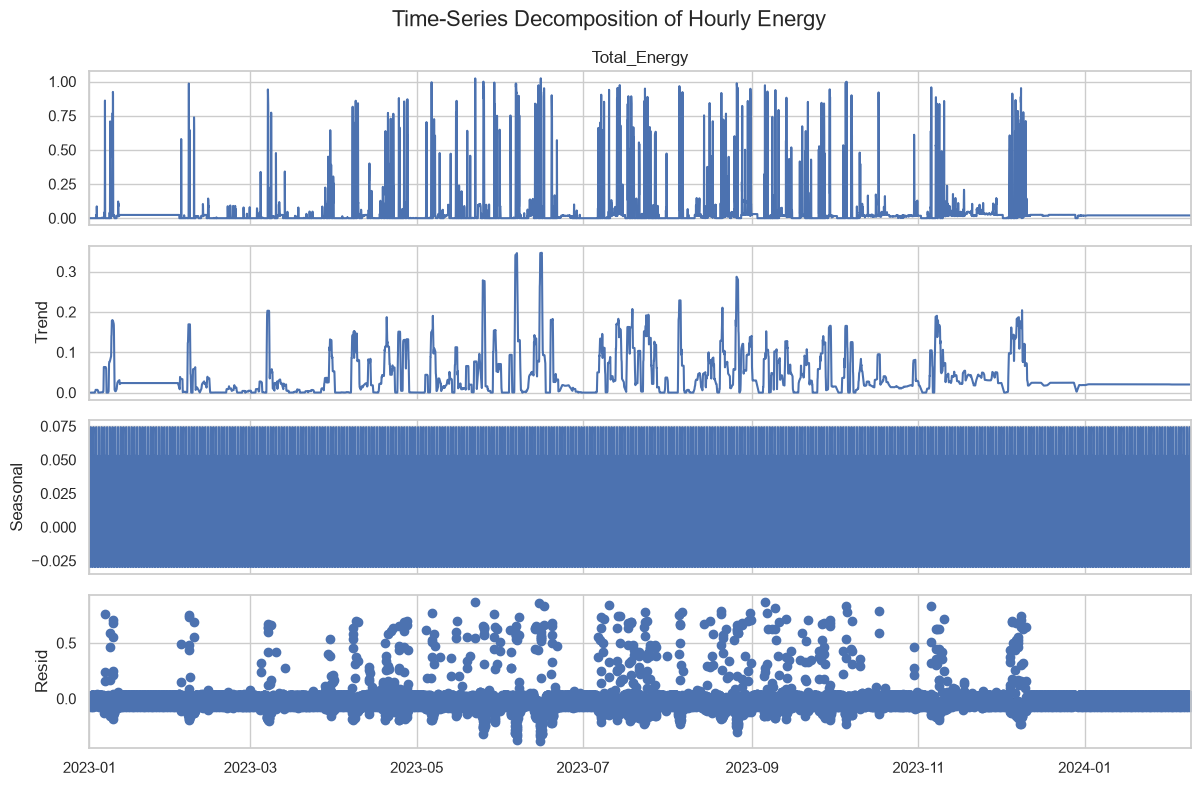

In [3]:
# 1. Correlation Matrix
cols_for_corr = ['CO2_indoor', 'Temp_indoor', 'RH_indoor', 'CO2_outdoor', 'Temp_outdoor', 'Total_Energy']
plt.figure(figsize=(10, 6))
sns.heatmap(df[cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 2. Time-Series Decomposition
hourly_energy = df.set_index('Datetime')['Total_Energy'].resample('h').mean().ffill().bfill()
decomposition = seasonal_decompose(hourly_energy, model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time-Series Decomposition of Hourly Energy', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Occupancy Pattern Detection (Clustering)
Using K-Means clustering on CO2, Temperature, and Total Energy to define distinct occupancy states.

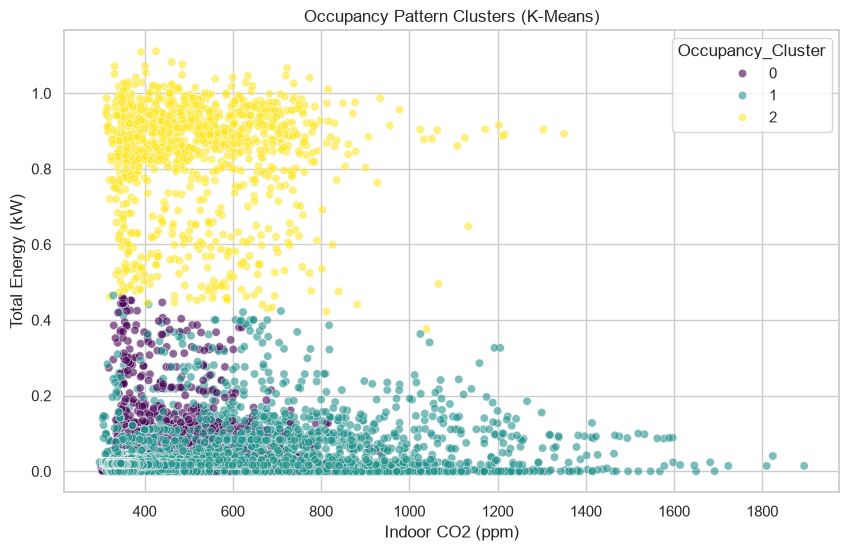

In [4]:
cluster_df = df.dropna(subset=['CO2_indoor', 'Temp_indoor', 'Total_Energy']).copy()
X = cluster_df[['CO2_indoor', 'Temp_indoor', 'Total_Energy']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['Occupancy_Cluster'] = kmeans.fit_predict(X_scaled)

# Sort clusters by energy use to label them logically
cluster_means = cluster_df.groupby('Occupancy_Cluster')['Total_Energy'].mean().sort_values()
label_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_means.index)}
cluster_df['Occupancy_Cluster'] = cluster_df['Occupancy_Cluster'].map(label_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x='CO2_indoor', y='Total_Energy', hue='Occupancy_Cluster', palette='viridis', alpha=0.6)
plt.title('Occupancy Pattern Clusters (K-Means)')
plt.xlabel('Indoor CO2 (ppm)')
plt.ylabel('Total Energy (kW)')
plt.show()

## 5. Predictive Modelling (Regression & Random Forest)
Predicting Total Energy demand based on Indoor and Outdoor Air Quality factors.

Data Split -> Train: 198 | Eval: 43 | Test: 43

--- Linear Regression ---
Eval R2: 0.1895 | Eval RMSE: 0.0106
Test R2: 0.0154 | Test RMSE: 0.0172



--- Random Forest ---
Eval R2: 0.1786 | Eval RMSE: 0.0107
Test R2: -0.0278 | Test RMSE: 0.0176


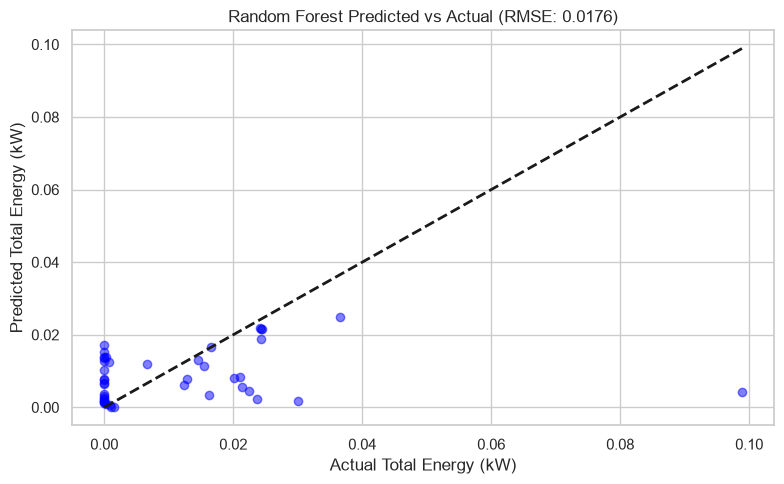

In [5]:
df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

features = ['CO2_indoor', 'Temp_indoor', 'RH_indoor', 'CO2_outdoor', 'Temp_outdoor', 'Hour', 'DayOfWeek']
model_df = df.dropna(subset=features + ['Total_Energy'])
X = model_df[features]
y = model_df['Total_Energy']

# Train, Eval, Test Split (70% Train, 15% Eval, 15% Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_eval, y_train, y_eval = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)
print(f"Data Split -> Train: {len(X_train)} | Eval: {len(X_eval)} | Test: {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_eval_lr = lr.predict(X_eval)
y_pred_test_lr = lr.predict(X_test)
print("\n--- Linear Regression ---")
print(f"Eval R2: {r2_score(y_eval, y_pred_eval_lr):.4f} | Eval RMSE: {np.sqrt(mean_squared_error(y_eval, y_pred_eval_lr)):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_test_lr):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_lr)):.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_eval_rf = rf.predict(X_eval)
y_pred_test_rf = rf.predict(X_test)
print("\n--- Random Forest ---")
print(f"Eval R2: {r2_score(y_eval, y_pred_eval_rf):.4f} | Eval RMSE: {np.sqrt(mean_squared_error(y_eval, y_pred_eval_rf)):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_test_rf):.4f} | Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):.4f}")

# Plot Actual vs Predicted (Random Forest Test Set)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test_rf, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Total Energy (kW)')
plt.ylabel('Predicted Total Energy (kW)')
plt.title(f'Random Forest Predicted vs Actual (RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):.4f})')
plt.tight_layout()
plt.show()


Training ARIMA model...
ARIMA Test RMSE: 0.0194 kW


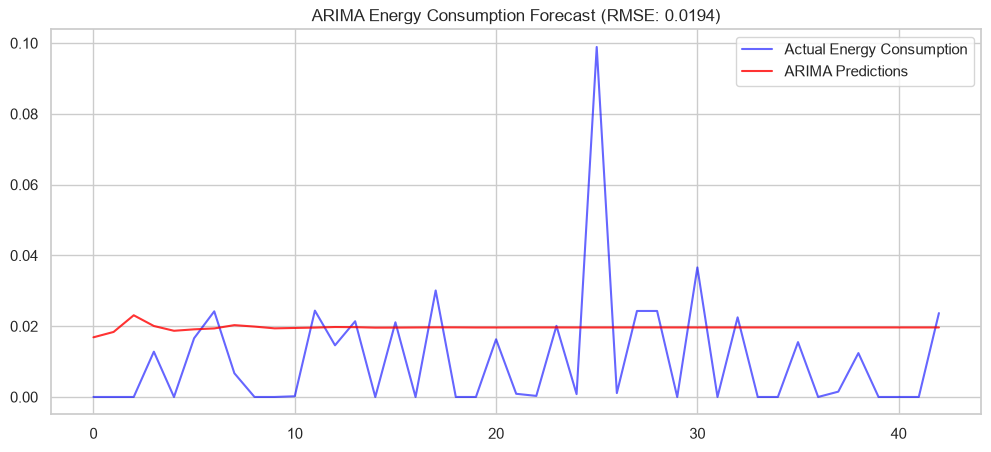

In [6]:
# --- ARIMA Time-Series Forecasting ---
from statsmodels.tsa.arima.model import ARIMA

print("Training ARIMA model...")
arima_model = ARIMA(y_train, order=(5,1,0))
arima_fit = arima_model.fit()
y_pred_arima = arima_fit.forecast(steps=len(y_test))

arima_rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))
print(f"ARIMA Test RMSE: {arima_rmse:.4f} kW")

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Energy Consumption', color='blue', alpha=0.6)
plt.plot(y_pred_arima.values, label='ARIMA Predictions', color='red', alpha=0.8)
plt.title(f'ARIMA Energy Consumption Forecast (RMSE: {arima_rmse:.4f})')
plt.legend()
plt.show()


Training LSTM Neural Network...


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


LSTM Test RMSE: 0.0176 kW


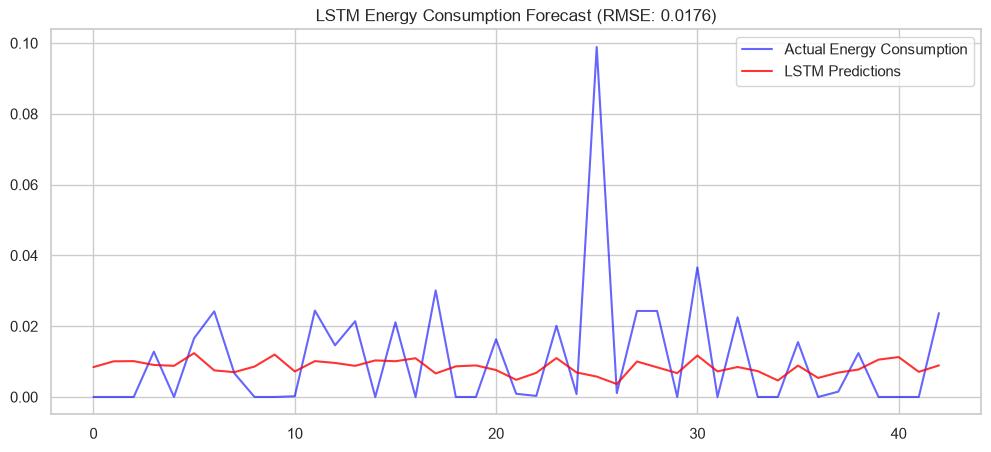

In [7]:
# --- LSTM Deep Learning Forecasting ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

print("Training LSTM Neural Network...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mse', optimizer='adam')

lstm_model.fit(X_train_lstm, y_train_scaled, epochs=10, batch_size=32, verbose=0, shuffle=False)

y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
print(f"LSTM Test RMSE: {lstm_rmse:.4f} kW")

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Energy Consumption', color='blue', alpha=0.6)
plt.plot(y_pred_lstm, label='LSTM Predictions', color='red', alpha=0.8)
plt.title(f'LSTM Energy Consumption Forecast (RMSE: {lstm_rmse:.4f})')
plt.legend()
plt.show()


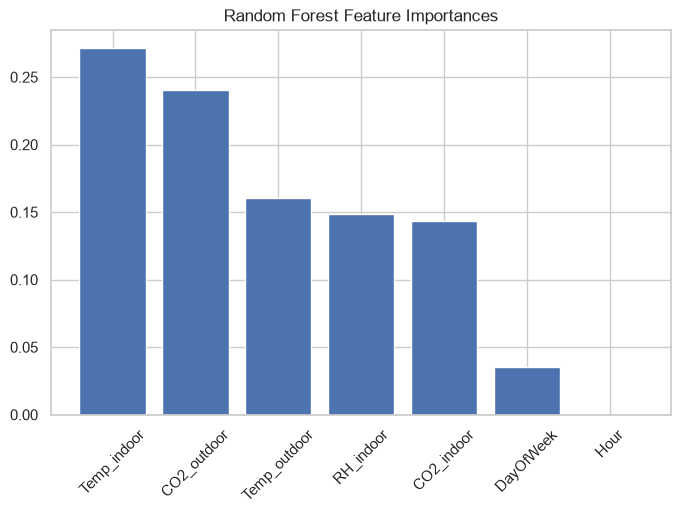

In [8]:
# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 5))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.show()